<a href="https://colab.research.google.com/github/prodigal94/food-safe-bots/blob/main/Week_3_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql import SparkSession
from pyspark.ml.regression import LinearRegression
from pyspark.sql.functions import log

In [ ]:
# Initialize Spark with optimizations for large data
spark = SparkSession.builder \
    .appName("BDA_Project") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = spark.read.parquet("/content/drive/MyDrive/Parquet/02_AgriTrade_ValueOnly.parquet")
df = df.withColumn("logValue", log(df["Value"]))

In [ ]:
train, test = df.randomSplit([.8,.2], seed = 6942067)
print(f"Train Data: {train.count()}, Test Data: {test.count()}")

Train Data: 3451681, Test Data: 863720


In [ ]:
# TIME-BASED TRAIN-TEST SPLIT
# Get the minimum and maximum year from the dataset
# This helps to divide the data based on time instead of random splitting
year_summary = df.select(
    F.min("Year").alias("min_year"),
    F.max("Year").alias("max_year")
).collect()[0]

# Store the minimum and maximum year values
min_year = year_summary["min_year"]
max_year = year_summary["max_year"]

# Compute the split year
# 80% of the earlier years will be used for training
# The remaining later years will be used for testing
split_year = int(min_year + ((max_year - min_year) * 0.8))

# Use older years as training data
train = df.filter(F.col("Year") <= split_year)

# Use newer years as testing data
test = df.filter(F.col("Year") > split_year)

# Display the split information
print("Minimum Year:", min_year)
print("Maximum Year:", max_year)
print("Split Year:", split_year)
print("Training Records:", train.count())
print("Testing Records:", test.count())

Minimum Year: 1961
Maximum Year: 2024
Split Year: 2011
Training Records: 2902140
Testing Records: 1413261


In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

#

country_indexer = StringIndexer(inputCol="Area", outputCol="Area_index", handleInvalid="keep")
item_indexer = StringIndexer(inputCol="Item", outputCol="Item_index", handleInvalid="keep")

encoder = OneHotEncoder(
    inputCols=["Area_index", "Item_index"],
    outputCols=["Area_vec", "Item_vec"]
)

assembler = VectorAssembler(
    inputCols=["Year", "Area_vec", "Item_vec"],
    outputCol="features"
)

lrModel = LinearRegression(featuresCol="features", labelCol="logValue")
pipeline = Pipeline(stages=[
    country_indexer,
    item_indexer,
    encoder,
    assembler,
    lrModel
])

model = pipeline.fit(train)

predictions = model.transform(test)
predictions.select("Area", "Item", "Year", "logValue", "Prediction").orderBy("Value", ascending=False).show()

+--------------------+--------------------+----+------------------+------------------+
|                Area|                Item|Year|          logValue|        Prediction|
+--------------------+--------------------+----+------------------+------------------+
|               China|Total Merchandise...|2024|  22.2704769200899|19.349354037933537|
|China (excluding ...|Total Merchandise...|2024|  22.2704769200899| 19.18744957182821|
|               China|Total Merchandise...|2022|22.267184008230664|19.253922155177264|
|China (excluding ...|Total Merchandise...|2022|22.267184008230664|19.092017689071938|
|               China|Total Merchandise...|2021|22.223597241803223| 19.20620621379912|
|China (excluding ...|Total Merchandise...|2021|22.223597241803223|19.044301747693794|
|               China|Total Merchandise...|2023|22.202113485222867|19.301638096555408|
|China (excluding ...|Total Merchandise...|2023|22.202113485222867| 19.13973363045008|
|               China|Total Merchandise...|

In [ ]:
# TEST SET MODEL EVALUATION
# Import evaluator for regression models
from pyspark.ml.evaluation import RegressionEvaluator

# RMSE shows the average prediction error
# Lower RMSE means better model performance
rmse_evaluator = RegressionEvaluator(
    labelCol="logValue",
    predictionCol="prediction",
    metricName="rmse"
)

# MAE shows the average absolute error between actual and predicted values
# Lower MAE means the predictions are closer to the actual values
mae_evaluator = RegressionEvaluator(
    labelCol="logValue",
    predictionCol="prediction",
    metricName="mae"
)

# R2 shows how much of the variation in the data is explained by the model
# A higher R2 means the model explains the data better
r2_evaluator = RegressionEvaluator(
    labelCol="logValue",
    predictionCol="prediction",
    metricName="r2"
)

# Evaluate the model using the test dataset
rmse = rmse_evaluator.evaluate(predictions)
mae = mae_evaluator.evaluate(predictions)
r2 = r2_evaluator.evaluate(predictions)

# Display the model performance results
print("Test Set Evaluation Results")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

Test Set Evaluation Results
RMSE: 2.634867484443938
MAE: 2.0835341243733305
R2: 0.49564671368358415


In [ ]:
### Evaluation
lr_model = model.stages[-1]
training_summary = lr_model.summary

print(f"RMSE: {training_summary.rootMeanSquaredError}")
print(f"R2: {training_summary.r2}")

RMSE: 2.3303753638844187
R2: 0.5185211558982215


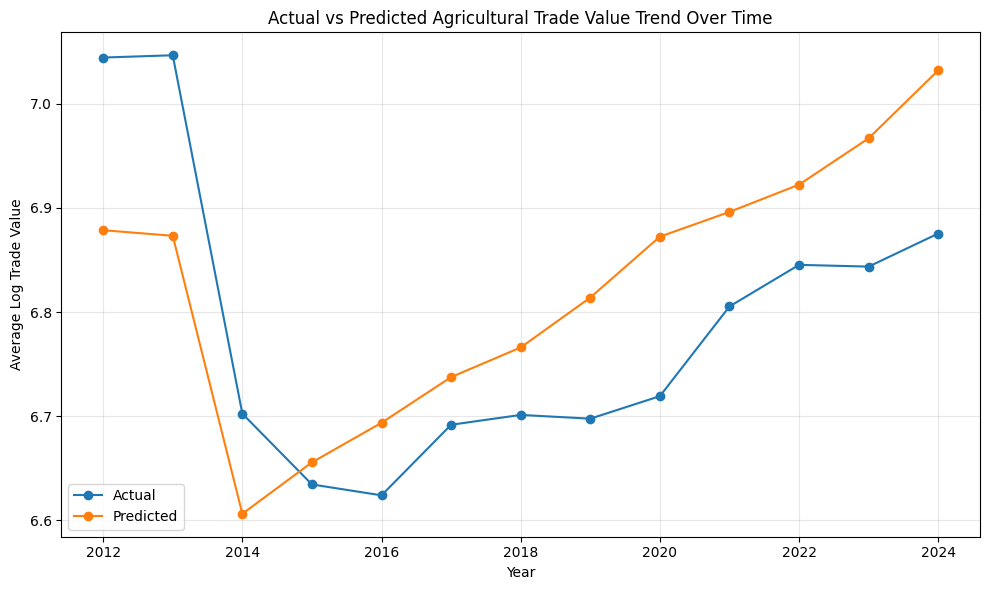

In [ ]:
# ACTUAL VS PREDICTED TRADE TREND OVER TIME

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Group the test predictions by year
# This allows us to compare the average actual and predicted trade values per year
trend_results = predictions.groupBy("Year").agg(
    F.avg("logValue").alias("Actual_Avg_LogValue"),
    F.avg("prediction").alias("Predicted_Avg_LogValue")
).orderBy("Year")

# Convert Spark DataFrame to Pandas DataFrame for plotting
trend_pd = trend_results.toPandas()

# Create the line graph
plt.figure(figsize=(10, 6))

# Plot the actual average log trade values
plt.plot(
    trend_pd["Year"],
    trend_pd["Actual_Avg_LogValue"],
    marker="o",
    label="Actual"
)

# Plot the predicted average log trade values
plt.plot(
    trend_pd["Year"],
    trend_pd["Predicted_Avg_LogValue"],
    marker="o",
    label="Predicted"
)

# Add graph title and labels
plt.title("Actual vs Predicted Agricultural Trade Value Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average Log Trade Value")

# Add legend and grid for readability
plt.legend()
plt.grid(True, alpha=0.3)

# Display the graph
plt.tight_layout()
plt.show()

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

print("=== DATA INSPECTION ===")
print("\nUnique Elements in dataset:")
df.select("Element").distinct().show(20, truncate=False)

print("\nSample of data (first 5 rows):")
df.show(5, truncate=False)

print(f"\nTotal records in df: {df.count():,}")

# Find Import-related Elements
import_elements = [
    row.Element
        for row in df.select("Element").distinct().collect()
            if row.Element is not None and "import" in row.Element.lower()
            ]

            print(f"\nFound Import-related Elements: {import_elements}")

            if len(import_elements) == 0:
                print("No Import-related Element found. Using all data.")
                    df_trade = df
                    else:
                        import_element = import_elements[0]
                            print(f"Using Element: {import_element}")
                                df_trade = df.filter(F.col("Element") == import_element)

                                print(f"Records after filtering: {df_trade.count():,}")

                                if df_trade.count() == 0:
                                    print("No data available.")
                                    else:
                                        window_spec = Window.partitionBy("Area", "Item").orderBy("Year")

                                            df_features = df_trade.withColumn(
                                                    "Value_prev", F.lag("Value").over(window_spec)
                                                        ).withColumn(
                                                                "YoY_Change",
                                                                        F.when(
                                                                                    F.col("Value_prev").isNull() | (F.col("Value_prev") == 0), 0
                                                                                            ).otherwise(
                                                                                                        ((F.col("Value") - F.col("Value_prev")) / F.col("Value_prev")) * 100
                                                                                                                )
                                                                                                                    )

                                                                                                                        df_features = df_features.na.fill(0)

                                                                                                                            area_year_features = df_features.groupBy("Area", "Year").agg(
                                                                                                                                    F.countDistinct("Item").alias("num_products"),
                                                                                                                                            F.sum("Value").alias("total_volume"),
                                                                                                                                                    F.avg("YoY_Change").alias("avg_growth")
                                                                                                                                                        )

                                                                                                                                                            area_year_features = area_year_features.na.fill(0)
                                                                                                                                                                area_year_features = area_year_features.filter(F.col("total_volume") > 0)

                                                                                                                                                                    print(f"\nRecords after aggregation (Area-Year): {area_year_features.count():,}")
                                                                                                                                                                        area_year_features.show(10, truncate=False)
